<a href="https://colab.research.google.com/github/LOKCHAND7/Data-Structures-And-Algorithm/blob/main/ainoisecancellationmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install librosa soundfile torch torchaudio pandas matplotlib

In [6]:
import os
import glob
import random
import zipfile
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cpu
GPU available: False


In [7]:
!wget -q https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip
!unzip -q master.zip

print("ESC-50 downloaded.")

ESC-50 downloaded.


In [8]:
noise_files = glob.glob(
    "/content/ESC-50-master/audio/*.wav"
)

print("Number of noise files:", len(noise_files))
print(noise_files[:5])

Number of noise files: 2000
['/content/ESC-50-master/audio/1-39901-A-11.wav', '/content/ESC-50-master/audio/4-168155-A-15.wav', '/content/ESC-50-master/audio/4-184235-A-28.wav', '/content/ESC-50-master/audio/2-72547-D-14.wav', '/content/ESC-50-master/audio/1-49098-A-35.wav']


In [9]:
metadata = pd.read_csv(
    "/content/ESC-50-master/meta/esc50.csv"
)

print(metadata["category"].unique())

['dog' 'chirping_birds' 'vacuum_cleaner' 'thunderstorm' 'door_wood_knock'
 'can_opening' 'crow' 'clapping' 'fireworks' 'chainsaw' 'airplane'
 'mouse_click' 'pouring_water' 'train' 'sheep' 'water_drops'
 'church_bells' 'clock_alarm' 'keyboard_typing' 'wind' 'footsteps' 'frog'
 'cow' 'brushing_teeth' 'car_horn' 'crackling_fire' 'helicopter'
 'drinking_sipping' 'rain' 'insects' 'laughing' 'hen' 'engine' 'breathing'
 'crying_baby' 'hand_saw' 'coughing' 'glass_breaking' 'snoring'
 'toilet_flush' 'pig' 'washing_machine' 'clock_tick' 'sneezing' 'rooster'
 'sea_waves' 'siren' 'cat' 'door_wood_creaks' 'crickets']


In [10]:
!pip -q install datasets

In [11]:
from datasets import load_dataset

speech_dataset = load_dataset(
    "openslr/librispeech_asr",
    "clean",
    split="train.100",
    streaming=True
)

print("Dataset loaded.")

README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Dataset loaded.


In [12]:
os.makedirs("/content/speech", exist_ok=True)

count = 0

for item in speech_dataset:
    audio = item["audio"]

    waveform = np.array(audio["array"], dtype=np.float32)
    sr = audio["sampling_rate"]

    # Keep clips between roughly 2 and 6 seconds
    if len(waveform) >= sr * 2:
        filename = f"/content/speech/speech_{count:03d}.wav"
        sf.write(filename, waveform, sr)

        count += 1

    if count >= 30:
        break

print("Speech files created:", count)

Speech files created: 30


In [13]:
os.makedirs("/content/speech16", exist_ok=True)

speech_files = glob.glob("/content/speech/*.wav")

for i, file in enumerate(speech_files):
    y, sr = librosa.load(file, sr=16000, mono=True)

    # Normalize
    y = y / (np.max(np.abs(y)) + 1e-8)

    sf.write(
        f"/content/speech16/speech_{i:03d}.wav",
        y,
        16000
    )

print("Resampled:", len(speech_files), "speech files")

Resampled: 30 speech files


In [14]:
wanted_noises = [
    "engine",
    "helicopter",
    "wind",
    "siren",
    "train",
    "airplane",
    "chainsaw"
]

selected_noise = metadata[
    metadata["category"].isin(wanted_noises)
]

print(selected_noise["category"].value_counts())

category
chainsaw      40
airplane      40
train         40
wind          40
helicopter    40
engine        40
siren         40
Name: count, dtype: int64


In [16]:
def mix_at_snr(clean, noise, snr_db):

    # Make noise long enough
    if len(noise) < len(clean):
        repeats = int(np.ceil(len(clean) / len(noise)))
        noise = np.tile(noise, repeats)

    # Random section of noise
    start = random.randint(0, len(noise) - len(clean))
    noise = noise[start:start + len(clean)]

    # RMS values
    clean_rms = np.sqrt(np.mean(clean ** 2) + 1e-8)
    noise_rms = np.sqrt(np.mean(noise ** 2) + 1e-8)

    # Desired noise RMS
    desired_noise_rms = clean_rms / (10 ** (snr_db / 20))

    noise = noise * (desired_noise_rms / noise_rms)

    noisy = clean + noise

    # Prevent clipping
    max_val = np.max(np.abs(noisy))

    if max_val > 0.99:
        noisy = noisy / max_val

    return noisy.astype(np.float32)

In [31]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class AudioDenoisingDataset(Dataset):

    def __init__(self, pairs, sr=16000, duration=3.0):
        self.pairs = pairs
        self.sr = sr
        self.target_length = int(sr * duration)

    def fix_length(self, audio):
        # Cut audio if longer than 3 seconds
        if len(audio) > self.target_length:
            audio = audio[:self.target_length]

        # Add zeros if shorter than 3 seconds
        elif len(audio) < self.target_length:
            padding = self.target_length - len(audio)
            audio = np.pad(audio, (0, padding))

        return audio.astype(np.float32)

    def audio_to_spectrogram(self, audio):

        stft = librosa.stft(
            audio,
            n_fft=512,
            hop_length=128
        )

        magnitude = np.abs(stft)

        # Log magnitude
        spectrogram = np.log1p(magnitude)

        return spectrogram

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        noisy_path, clean_path = self.pairs[idx]

        # Load audio
        noisy, _ = librosa.load(
            noisy_path,
            sr=self.sr,
            mono=True
        )

        clean, _ = librosa.load(
            clean_path,
            sr=self.sr,
            mono=True
        )

        # IMPORTANT:
        # Make both exactly 3 seconds
        noisy = self.fix_length(noisy)
        clean = self.fix_length(clean)

        # Convert to spectrogram
        noisy_spec = self.audio_to_spectrogram(noisy)
        clean_spec = self.audio_to_spectrogram(clean)

        # Normalize using the noisy spectrogram statistics
        mean = noisy_spec.mean()
        std = noisy_spec.std() + 1e-8

        noisy_spec = (noisy_spec - mean) / std
        clean_spec = (clean_spec - mean) / std

        # Convert to PyTorch tensors
        noisy_spec = torch.tensor(
            noisy_spec,
            dtype=torch.float32
        ).unsqueeze(0)

        clean_spec = torch.tensor(
            clean_spec,
            dtype=torch.float32
        ).unsqueeze(0)

        return noisy_spec, clean_spec

In [32]:
train_dataset = AudioDenoisingDataset(
    train_pairs,
    sr=16000,
    duration=3.0
)

val_dataset = AudioDenoisingDataset(
    val_pairs,
    sr=16000,
    duration=3.0
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 800
Validation samples: 200


In [33]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [34]:
noisy_test, clean_test = next(iter(train_loader))

print("Noisy shape :", noisy_test.shape)
print("Clean shape :", clean_test.shape)

Noisy shape : torch.Size([4, 1, 257, 376])
Clean shape : torch.Size([4, 1, 257, 376])


In [35]:
import torch.nn as nn

class DenoisingCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Conv2d(
                1, 16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                32, 16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.Conv2d(
                16, 1,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):
        return self.network(x)

In [36]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = DenoisingCNN().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Using device: cpu


In [37]:
noisy, clean = next(iter(train_loader))

noisy = noisy.to(device)
clean = clean.to(device)

output = model(noisy)

print("Input shape :", noisy.shape)
print("Output shape:", output.shape)
print("Target shape:", clean.shape)

Input shape : torch.Size([4, 1, 257, 376])
Output shape: torch.Size([4, 1, 257, 376])
Target shape: torch.Size([4, 1, 257, 376])


In [38]:
epochs = 10

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for noisy, clean in train_loader:

        noisy = noisy.to(device)
        clean = clean.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # AI prediction
        output = model(noisy)

        # Compare prediction with clean speech
        loss = criterion(output, clean)

        # Calculate gradients
        loss.backward()

        # Update CNN weights
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"- Loss: {train_loss:.5f}"
    )

Epoch 1/10 - Loss: 0.22885
Epoch 2/10 - Loss: 0.15806
Epoch 3/10 - Loss: 0.13998
Epoch 4/10 - Loss: 0.13476
Epoch 5/10 - Loss: 0.12786
Epoch 6/10 - Loss: 0.12361
Epoch 7/10 - Loss: 0.11923
Epoch 8/10 - Loss: 0.11610
Epoch 9/10 - Loss: 0.11352
Epoch 10/10 - Loss: 0.11130


In [39]:
torch.save(model.state_dict(), "speech_enhancement_cnn.pth")

print("Model saved successfully.")

Model saved successfully.


In [40]:
from google.colab import output
from IPython.display import Audio, display
import base64
import io
import wave

def record_audio(seconds=5):
    js = f"""
    async function recordAudio() {{
        const stream = await navigator.mediaDevices.getUserMedia({{audio: true}});
        const recorder = new MediaRecorder(stream);
        const chunks = [];

        recorder.ondataavailable = e => chunks.push(e.data);

        recorder.start();

        await new Promise(resolve => setTimeout(resolve, {seconds * 1000}));

        recorder.stop();

        await new Promise(resolve => recorder.onstop = resolve);

        stream.getTracks().forEach(track => track.stop());

        const blob = new Blob(chunks, {{type: 'audio/webm'}});
        const arrayBuffer = await blob.arrayBuffer();

        return Array.from(new Uint8Array(arrayBuffer));
    }}

    recordAudio();
    """

    data = output.eval_js(js)

    return bytes(data)

recording process

In [47]:
audio_bytes = record_audio(5)

with open("my_clean_voice.webm", "wb") as f:
    f.write(audio_bytes)

print("Recording completed.")

Recording completed.


your recording

In [48]:
display(Audio("my_clean_voice.webm"))

Convert your recording to 16 kHz WAV

In [49]:
import librosa
import soundfile as sf

clean_audio, sr = librosa.load(
    "my_clean_voice.webm",
    sr=16000,
    mono=True
)

sf.write(
    "my_clean_voice.wav",
    clean_audio,
    16000
)

print("Audio converted to 16 kHz.")
print("Samples:", len(clean_audio))

/tmp/ipykernel_1625/3998277985.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  clean_audio, sr = librosa.load(
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Audio converted to 16 kHz.
Samples: 77760


Create noise

In [50]:
import os

noise_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.lower().endswith((".wav", ".mp3", ".flac")):
            noise_files.append(os.path.join(root, file))

print("Audio files found:", len(noise_files))

for f in noise_files[:20]:
    print(f)

Audio files found: 4061
/content/my_clean_voice.wav
/content/clean_dataset/00959.wav
/content/clean_dataset/00815.wav
/content/clean_dataset/00487.wav
/content/clean_dataset/00204.wav
/content/clean_dataset/00331.wav
/content/clean_dataset/00269.wav
/content/clean_dataset/00323.wav
/content/clean_dataset/00581.wav
/content/clean_dataset/00301.wav
/content/clean_dataset/00966.wav
/content/clean_dataset/00116.wav
/content/clean_dataset/00132.wav
/content/clean_dataset/00930.wav
/content/clean_dataset/00831.wav
/content/clean_dataset/00984.wav
/content/clean_dataset/00573.wav
/content/clean_dataset/00221.wav
/content/clean_dataset/00084.wav
/content/clean_dataset/00892.wav


Choose one noise file

Choose one noise file

In [51]:
# Pick one noise file from the downloaded noise dataset

noise_path = "/content/clean_dataset/00959.wav"

print("Selected noise:")
print(noise_path)

Selected noise:
/content/clean_dataset/00959.wav


Find the actual noise dataset

In [52]:
import os

print("Folders inside /content:\n")

for item in os.listdir("/content"):
    path = os.path.join("/content", item)
    if os.path.isdir(path):
        print(item)

Folders inside /content:

.config
clean_dataset
speech
ESC-50-master
noisy_dataset
speech16
sample_data


See the noise categories

In [53]:
import os

esc_path = "/content/ESC-50-master"

print("ESC-50 contents:")
for item in os.listdir(esc_path):
    print(item)

ESC-50 contents:
.circleci
audio
esc50.gif
.gitignore
tests
requirements.txt
pytest.ini
README.md
LICENSE
meta
.github


See the available noise labels

In [54]:
import pandas as pd
import os

meta_path = "/content/ESC-50-master/meta/esc50.csv"

esc_meta = pd.read_csv(meta_path)

print("Columns:")
print(esc_meta.columns.tolist())

print("\nNoise categories:")
print(sorted(esc_meta["category"].unique()))

Columns:
['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']

Noise categories:
['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']


 Select helicopter noise

In [55]:
# Select helicopter recordings from ESC-50

helicopter_files = esc_meta[
    esc_meta["category"] == "helicopter"
]["filename"].tolist()

print("Number of helicopter recordings:", len(helicopter_files))

print("\nFirst 10 files:")
for f in helicopter_files[:10]:
    print(f)

Number of helicopter recordings: 40

First 10 files:
1-172649-A-40.wav
1-172649-B-40.wav
1-172649-C-40.wav
1-172649-D-40.wav
1-172649-E-40.wav
1-172649-F-40.wav
1-181071-A-40.wav
1-181071-B-40.wav
2-188822-A-40.wav
2-188822-B-40.wav


Select and listen to one helicopter recording

In [56]:
noise_file = helicopter_files[0]

noise_path = os.path.join(
    "/content/ESC-50-master/audio",
    noise_file
)

print("Selected noise:")
print(noise_path)

Selected noise:
/content/ESC-50-master/audio/1-172649-A-40.wav


In [57]:
from IPython.display import Audio, display

display(Audio(noise_path))

Prepare your voice and helicopter noise

In [58]:
import librosa
import numpy as np
import soundfile as sf

TARGET_SR = 16000
TARGET_LENGTH = 3 * TARGET_SR  # 3 seconds = 48,000 samples

# -----------------------------
# Load your clean voice
# -----------------------------
clean_audio, _ = librosa.load(
    "/content/my_clean_voice.wav",
    sr=TARGET_SR,
    mono=True
)

# Keep exactly 3 seconds
clean_audio = clean_audio[:TARGET_LENGTH]

# Pad if recording is shorter than 3 seconds
if len(clean_audio) < TARGET_LENGTH:
    clean_audio = np.pad(
        clean_audio,
        (0, TARGET_LENGTH - len(clean_audio))
    )

# -----------------------------
# Load helicopter noise
# -----------------------------
noise_audio, _ = librosa.load(
    noise_path,
    sr=TARGET_SR,
    mono=True
)

# Make helicopter noise exactly 3 seconds
if len(noise_audio) > TARGET_LENGTH:
    noise_audio = noise_audio[:TARGET_LENGTH]
else:
    repeats = int(np.ceil(TARGET_LENGTH / len(noise_audio)))
    noise_audio = np.tile(noise_audio, repeats)[:TARGET_LENGTH]

print("Clean voice samples :", len(clean_audio))
print("Noise samples       :", len(noise_audio))
print("Sample rate         :", TARGET_SR)
print("Duration            :", TARGET_LENGTH / TARGET_SR, "seconds")

Clean voice samples : 48000
Noise samples       : 48000
Sample rate         : 16000
Duration            : 3.0 seconds


Create noisy speech at 5 dB SNR$0

In [59]:
def mix_at_snr(clean, noise, snr_db):
    clean_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)

    target_noise_power = clean_power / (10 ** (snr_db / 10))

    noise_scaled = noise * np.sqrt(
        target_noise_power / (noise_power + 1e-12)
    )

    noisy = clean + noise_scaled

    # Prevent clipping
    max_val = np.max(np.abs(noisy))

    if max_val > 0.99:
        noisy = noisy / max_val * 0.99

    return noisy.astype(np.float32), noise_scaled.astype(np.float32)


noisy_audio, scaled_noise = mix_at_snr(
    clean_audio,
    noise_audio,
    snr_db=5
)

print("Noisy speech created successfully.")
print("Target SNR: 5 dB")
print("Samples:", len(noisy_audio))

Noisy speech created successfully.
Target SNR: 5 dB
Samples: 48000


Save the noisy speech

In [60]:
sf.write(
    "/content/my_noisy_helicopter.wav",
    noisy_audio,
    TARGET_SR
)

print("Saved successfully:")
print("/content/my_noisy_helicopter.wav")

Saved successfully:
/content/my_noisy_helicopter.wav


Listen to clean and noisy speech

In [61]:
from IPython.display import Audio, display

print("1. CLEAN SPEECH")
display(Audio("/content/my_clean_voice.wav"))

print("2. NOISY SPEECH - HELICOPTER - 5 dB SNR")
display(Audio("/content/my_noisy_helicopter.wav"))

1. CLEAN SPEECH


2. NOISY SPEECH - HELICOPTER - 5 dB SNR


Load your trained CNN

In [62]:
import torch

model = DenoisingCNN().to(device)

model.load_state_dict(
    torch.load(
        "speech_enhancement_cnn.pth",
        map_location=device
    )
)

model.eval()

print("Trained CNN loaded successfully.")
print("Device:", device)

Trained CNN loaded successfully.
Device: cpu


Convert noisy speech to spectrogram

In [63]:
noisy_stft = librosa.stft(
    noisy_audio,
    n_fft=512,
    hop_length=128
)

noisy_magnitude = np.abs(noisy_stft)

noisy_spec = np.log1p(noisy_magnitude)

# Normalize exactly like training
spec_mean = noisy_spec.mean()
spec_std = noisy_spec.std() + 1e-8

noisy_input = (
    noisy_spec - spec_mean
) / spec_std

noisy_tensor = torch.tensor(
    noisy_input,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(device)

print("CNN input shape:", noisy_tensor.shape)

CNN input shape: torch.Size([1, 1, 257, 376])


Run the CNN

In [64]:
with torch.no_grad():
    enhanced_output = model(noisy_tensor)

enhanced_spec = enhanced_output.squeeze().cpu().numpy()

print("CNN enhancement completed.")
print("Output shape:", enhanced_spec.shape)

CNN enhancement completed.
Output shape: (257, 376)


Convert CNN output back to magnitude

In [65]:
enhanced_spec = (
    enhanced_spec * spec_std
    + spec_mean
)

enhanced_magnitude = np.expm1(enhanced_spec)

# Remove numerical negative values
enhanced_magnitude = np.maximum(
    enhanced_magnitude,
    0
)

print("Enhanced magnitude generated.")
print("Shape:", enhanced_magnitude.shape)

Enhanced magnitude generated.
Shape: (257, 376)


Reconstruct enhanced audio

In [66]:
noisy_phase = np.angle(noisy_stft)

enhanced_stft = (
    enhanced_magnitude *
    np.exp(1j * noisy_phase)
)

enhanced_audio = librosa.istft(
    enhanced_stft,
    hop_length=128,
    length=TARGET_LENGTH
)

# Prevent clipping
max_val = np.max(np.abs(enhanced_audio))

if max_val > 0.99:
    enhanced_audio = (
        enhanced_audio / max_val * 0.99
    )

enhanced_audio = enhanced_audio.astype(np.float32)

print("Enhanced audio reconstructed.")
print("Samples:", len(enhanced_audio))

Enhanced audio reconstructed.
Samples: 48000


Save enhanced speech

In [67]:
enhanced_path = "/content/my_enhanced_helicopter.wav"

sf.write(
    enhanced_path,
    enhanced_audio,
    TARGET_SR
)

print("Enhanced speech saved:")
print(enhanced_path)

Enhanced speech saved:
/content/my_enhanced_helicopter.wav


Listen to all three 🎧

In [68]:
print("========== CLEAN SPEECH ==========")
display(Audio("/content/my_clean_voice.wav"))

print("========== NOISY SPEECH ==========")
display(Audio("/content/my_noisy_helicopter.wav"))

print("========== CNN ENHANCED SPEECH ==========")
display(Audio("/content/my_enhanced_helicopter.wav"))

========== CLEAN SPEECH ==========


========== NOISY SPEECH ==========


========== CNN ENHANCED SPEECH ==========


Calculate input and output SNR

In [69]:
def calculate_snr(clean, test):
    error = clean - test

    signal_power = np.mean(clean ** 2)
    error_power = np.mean(error ** 2)

    return 10 * np.log10(
        signal_power / (error_power + 1e-12)
    )


input_snr = calculate_snr(
    clean_audio,
    noisy_audio
)

output_snr = calculate_snr(
    clean_audio,
    enhanced_audio
)

snr_improvement = output_snr - input_snr

print(f"Input SNR       : {input_snr:.2f} dB")
print(f"Output SNR      : {output_snr:.2f} dB")
print(f"SNR Improvement : {snr_improvement:.2f} dB")

Input SNR       : 5.00 dB
Output SNR      : 8.81 dB
SNR Improvement : 3.81 dB


 Create SNR graph

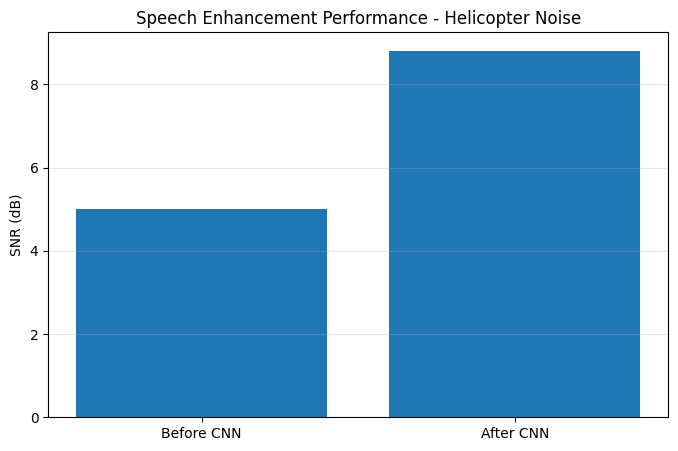

In [70]:
import matplotlib.pyplot as plt

labels = ["Before CNN", "After CNN"]
snr_values = [input_snr, output_snr]

plt.figure(figsize=(8, 5))

plt.bar(labels, snr_values)

plt.ylabel("SNR (dB)")
plt.title("Speech Enhancement Performance - Helicopter Noise")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

Create waveform comparison

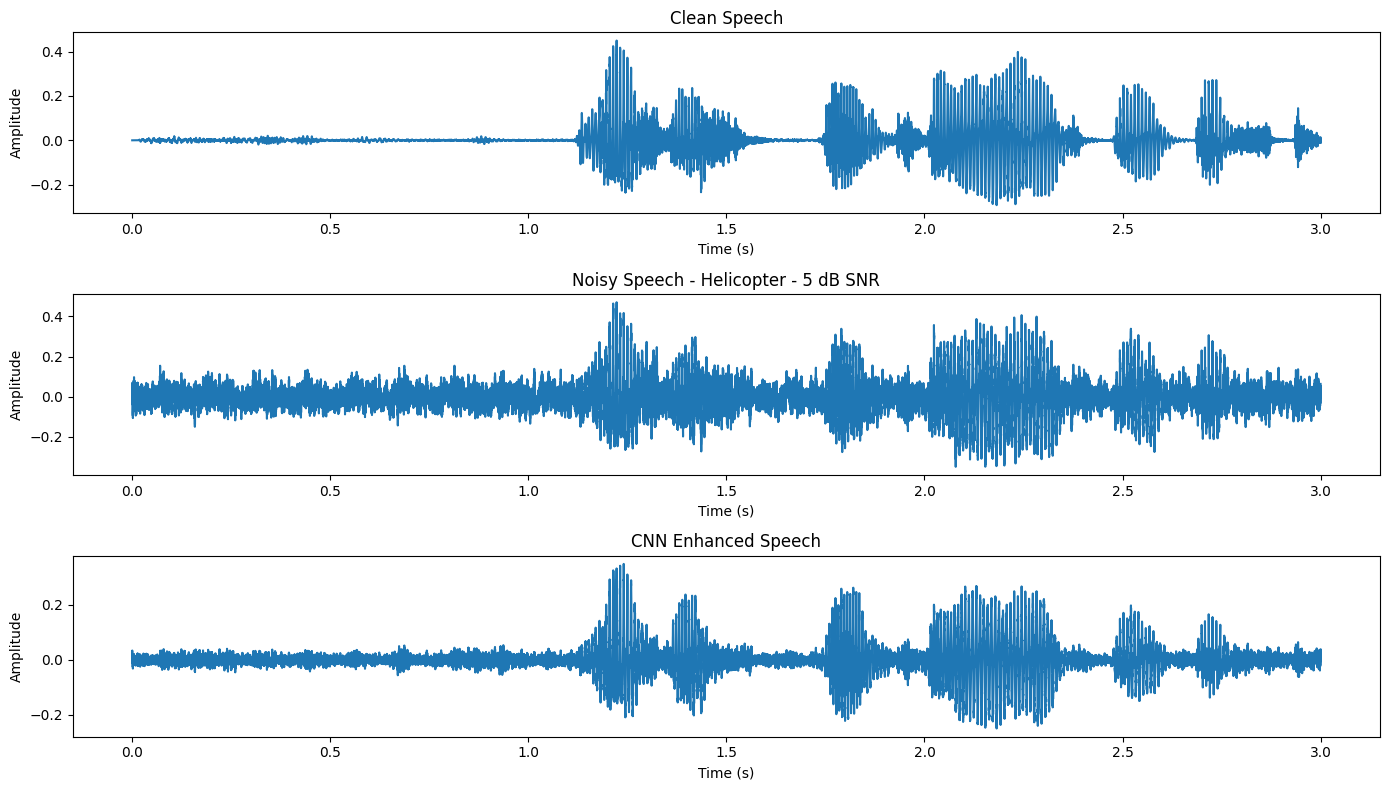

In [71]:
time = np.arange(TARGET_LENGTH) / TARGET_SR

plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(time, clean_audio)
plt.title("Clean Speech")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 2)
plt.plot(time, noisy_audio)
plt.title("Noisy Speech - Helicopter - 5 dB SNR")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 3)
plt.plot(time, enhanced_audio)
plt.title("CNN Enhanced Speech")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

Create spectrogram comparison

In [72]:
import librosa.display

def get_spectrogram_db(audio):
    stft = librosa.stft(
        audio,
        n_fft=512,
        hop_length=128
    )

    magnitude = np.abs(stft)

    return librosa.amplitude_to_db(
        magnitude,
        ref=np.max
    )


clean_db = get_spectrogram_db(clean_audio)
noisy_db = get_spectrogram_db(noisy_audio)
enhanced_db = get_spectrogram_db(enhanced_audio)

print("Spectrograms calculated.")

Spectrograms calculated.


now plot

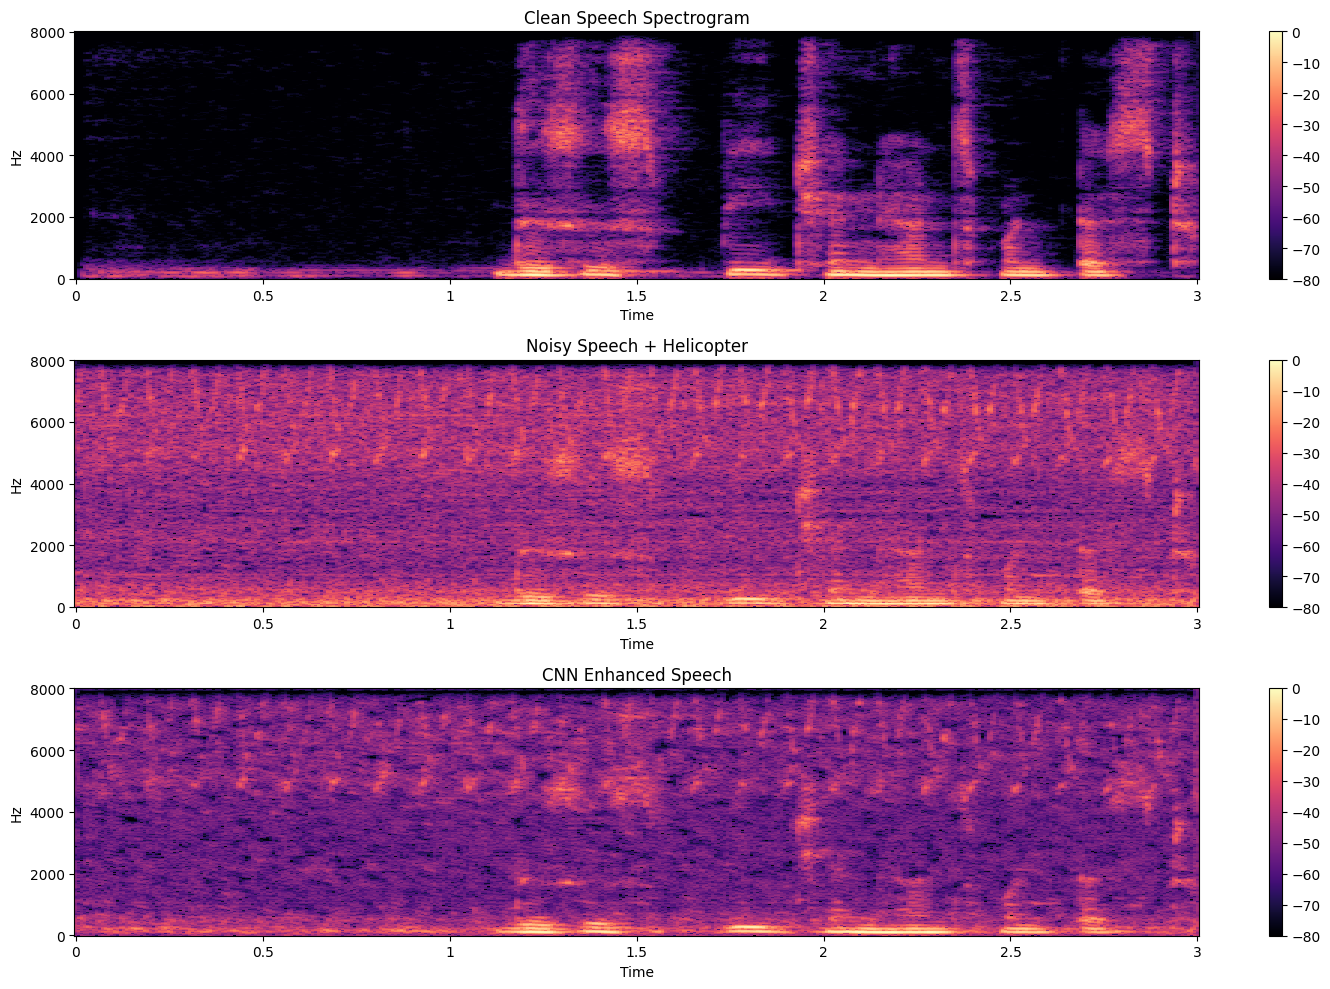

In [74]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)

librosa.display.specshow(
    clean_db,
    sr=TARGET_SR,
    hop_length=128,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar()
plt.title("Clean Speech Spectrogram")


plt.subplot(3, 1, 2)

librosa.display.specshow(
    noisy_db,
    sr=TARGET_SR,
    hop_length=128,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar()
plt.title("Noisy Speech + Helicopter")


plt.subplot(3, 1, 3)

librosa.display.specshow(
    enhanced_db,
    sr=TARGET_SR,
    hop_length=128,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar()
plt.title("CNN Enhanced Speech")


plt.tight_layout()
plt.show()

Create your training-loss graph

In [75]:
epochs = list(range(1, 11))

losses = [
    0.22885,
    0.15806,
    0.13998,
    0.13476,
    0.12786,
    0.12361,
    0.11923,
    0.11610,
    0.11352,
    0.11130
]

plot training-loss graph

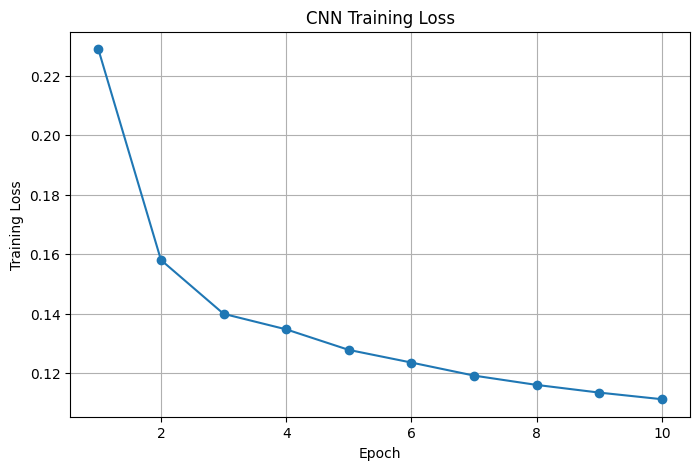

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")

plt.grid(True)

plt.show()

Create the final result table

In [77]:
results = {
    "Noise Type": "Helicopter",
    "Target Input SNR (dB)": 5,
    "Measured Input SNR (dB)": round(input_snr, 2),
    "Output SNR (dB)": round(output_snr, 2),
    "SNR Improvement (dB)": round(snr_improvement, 2)
}

for key, value in results.items():
    print(f"{key}: {value}")

Noise Type: Helicopter
Target Input SNR (dB): 5
Measured Input SNR (dB): 5.0
Output SNR (dB): 8.8100004196167
SNR Improvement (dB): 3.809999942779541
